* ### Next Token Visualization: We'll use Ollama (our local free frontier model) to create a graph of how an AI "thinks."

* ### Commercial Project Lab: We'll implement the entire flow of audio meeting minutes step-by-step in a notebook.

* ### Final Assignment: We'll build a "Synthetic Data Generator" that will generate fake data about employees or products for your business.

### Step 1: Ollama Install Karein

In [ ]:
# Installing the Python client to talk to the Ollama server
!pip install -q ollama

In [ ]:
# 1. First install zstd and pciutils
!sudo apt-get update
!sudo apt-get install -y zstd pciutils

# 2. Now install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,881 kB]
Get:13 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InR

### Step 2: Server ko Background mein Start karein

In [ ]:
import subprocess
import threading
import time

# Restarting the server thread
def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()

time.sleep(10) # Socket readiness wait
print("✅ Ollama server is now actually running!")

✅ Ollama server is now actually running!


### Step 3: Model Pull Karein

In [ ]:
# Downloading Llama 3.2 3B
!ollama pull llama3.2:3b

### Step 4: Next Token Prediction Visualization

In [ ]:
import ollama
import math

message = "In one sentence, describe the color orange to someone who has never been able to see"

# Getting top 3 predictions
response = ollama.chat(
    model='llama3.2:3b',
    messages=[{'role': 'user', 'content': message}],
    options={'num_predict': 1, 'logprobs': True, 'top_logprobs': 3}
)

print(f"Token predictions for: '{message}'\n")

# Check if logprobs exist and then access the correct structure
if response.logprobs and response.logprobs.content:
    for entry in response.logprobs.content[0].top_logprobs:
        prob = math.exp(entry.logprob) * 100
        print(f"Token: '{entry.token}' | Probability: {prob:.1f}%")
else:
    print("No log probabilities returned by the model.")

Token predictions for: 'In one sentence, describe the color orange to someone who has never been able to see'

No log probabilities returned by the model.


"Robust Error Handling" add

In [ ]:
import ollama
import math

message = "In one sentence, describe the color orange to someone who has never been able to see"

# 1. Calling the model
response = ollama.generate(
    model='llama3.2:3b',
    prompt=message,
    options={
        'num_predict': 1,
        'logprobs': True,
        'top_logprobs': 5,
        'temperature': 0
    }
)

print(f"Analyzing Token Probabilities for: '{message}'\n")

# 2. Converting Pydantic object to dictionary to avoid AttributeError
response_dict = response.model_dump()

# 3. Checking the structure safely
if 'sample_logprobs' in response_dict and response_dict['sample_logprobs']:
    # Looping through the first predicted token's logprobs
    for i, token_data in enumerate(response_dict['sample_logprobs']):
        print(f"--- Top Candidates for Next Token ---")
        for entry in token_data:
            token_str = entry.get('token', 'Unknown')
            log_val = entry.get('logprob', -100)

            # Math: e^(logprob) = Probability
            probability = math.exp(log_val) * 100
            print(f"Token: '{token_str}' | Probability: {probability:.2f}%")
else:
    print("Logprobs not found. Model said:", response_dict.get('response'))
    print("Available keys in response:", response_dict.keys())

Analyzing Token Probabilities for: 'In one sentence, describe the color orange to someone who has never been able to see'

Logprobs not found. Model said: The
Available keys in response: dict_keys(['model', 'created_at', 'done', 'done_reason', 'total_duration', 'load_duration', 'prompt_eval_count', 'prompt_eval_duration', 'eval_count', 'eval_duration', 'response', 'thinking', 'context', 'logprobs'])


# Commercial Project (Meeting Minutes)

# Create Meeting Minutes from an Audio File
The goal of this product is to use audio recording to generate professional meeting minutes, including action items.

## The Multi-modal Workflow:
1) Speech-to-Text: Converting audio to transcript.

2) Analysis: Using an LLM to summarize and extract tasks.

### Note: You can use the Denver City Council audio or record your own.

### Environment Setup for Product

In [ ]:
# Installing bitsandbytes for 4-bit quantization and accelerate for GPU management
!pip install -q --upgrade bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.1 MB/s eta 0:00:00


### Sign in & Constants

In [ ]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch
import gc

# Constants
LLAMA = "meta-llama/Llama-3.2-3B-Instruct"

# Logging in
hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

print("Setup for commercial product is ready!")

Setup for commercial product is ready!


* bitsandbytes: Without this, we can't load 3B or 8B models onto a free T4 GPU because they won't fit in memory.

* accelerate: This library helps "parallelize" the hardware so that transcription and inference can happen faster.

### Essential Imports

In [ ]:
# Importing libraries for multi-modal tasks (Audio + Text)
import os
import requests
from IPython.display import Markdown, display, update_display
from openai import OpenAI
from google.colab import drive
from huggingface_hub import login
from google.colab import userdata
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch

print("All engines are go! Libraries imported.")

All engines are go! Libraries imported.


### Defining the Model

In [ ]:
# Today we use the 'Chunkier' Llama 3.2 3B variant for better reasoning
LLAMA = "meta-llama/Llama-3.2-3B-Instruct"

# Connecting Google Drive
Download the denver_extract.mp3 file from the link provided in the intro.

Create a folder named llms in your Google Drive.

Upload the audio file there.

Run the cell below to mount your drive.

### Mounting the Drive

In [ ]:
# This will prompt you for permissions - click 'Allow' twice!
drive.mount("/content/drive")

# Defining the path to our audio file
audio_filename = "/content/drive/MyDrive/llms/denver_extract.mp3"

print(f"Drive mounted. Audio path set to: {audio_filename}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Audio path set to: /content/drive/MyDrive/llms/denver_extract.mp3


# Technical Analysis
* The "3B" Model: The 3B variant of Llama 3.2 is more intelligent than the 1B, but it takes up more memory. Therefore, we must strictly enforce 4-bit quantization.

* File Permissions: When you run drive.mount, Google Colab gets "Read/Write" access to your Drive so it can pull up the audio file.

* Constants: We've stored the model name as a constant in LLAMA so that if we want to change the model later, we only need to change it in one place.

# STEP 1: Transcribe Audio
In this step, we convert the audio recording of the Denver City Council meeting into a text transcript.

## Option 1: Open Source Transcription (Hugging Face Pipelines)
We are using OpenAI's Whisper model via the Hugging Face pipeline API.

* Model: openai/whisper-medium.en (Optimized for English).

* Hardware: Running on CUDA (T4 GPU) for maximum speed.

### Running the Transcription Pipeline

In [ ]:
# Importing the pipeline utility
from transformers import pipeline

# 1. Initialize the ASR (Automatic Speech Recognition) pipeline
pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-medium.en", # Using the open-source version
    torch_dtype=torch.float16,        # Precision setting for GPU speed
    device='cuda',                     # Ensure it runs on the T4 GPU
    return_timestamps=True
)

# 2. Run the transcription on our audio file
# This might take 1-2 minutes depending on the audio length
result = pipe(audio_filename)

# 3. Store and print the output
transcription = result["text"]
open_source_transcription = transcription # Saving for Step 2

print("--- Transcription Result ---")
print(transcription)

Device set to use cuda
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.


--- Transcription Result ---
 kind of the confluence of this whole idea of a Confluence Week, the merging of two rivers, and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now, and it's a very big issue. So that is the reason that the back of the logo is considered water. So I'll let you see the creation of the logo here. Yeah, so that basically kind of sums up the reason behind the logo and all the meanings behind the symbolism. And you'll hear a little bit more about our Confluence Week is basically highlighting all of these indigenous events and things that are happening around Denver so that we can kind of bring more people together and kind of share this whole idea of Indigenous Peoples Day. So, thank you. Thank you so much and thanks for your leadership. All right, welcome to the Denver City Council meeting of Monday, October 9th. Please rise with the Pledge of Allegiance by Councilman Lopez. I pledge a

## Technical Analysis
* The Whisper Model: Ed Donner mentioned that Whisper is an OpenAI model, but its "Medium" version is available for free on Hugging Face and is very accurate.

* Time Check: This step in Ed's video took approximately 2 minutes. If your audio snippet is longer, it may take a little longer.

* GPU Usage: Because we set device='cuda', you can see a graph of GPU activity (Compute) going up in Colab's "View Resources."

# STEP 2: Analyze & Report
We will now feed the transcript into Llama 3.2 to generate a structured report.

## Prompt Strategy:
* System Message: Defines the persona (a professional minutes-taker).

* User Prompt: Provides the transcript and specific formatting instructions (Markdown, no code blocks).

### Prompt Engineering

In [ ]:
# Defining the persona and instructions
system_message = """
You produce minutes of meetings from transcripts, with summary, key discussion points,
takeaways and action items with owners, in markdown format without code blocks.
"""

# Structuring the user input
user_prompt = f"""
Below is an extract transcript of a Denver council meeting.
Please write minutes in markdown without code blocks, including:
- a summary with attendees, location and date
- discussion points
- takeaways
- action items with owners

Transcription:
{transcription}
"""

# Preparing the message list
messages = [
    {"role": "system", "content": system_message},
    {"role": "user", "content": user_prompt}
]

### Model Inference with Streaming
We will apply 4-bit quantization (NF4) to ensure the 3B model fits comfortably on the T4 GPU.

In [ ]:
# 1. Setup 4-bit Quantization Config
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

# 2. Initialize Tokenizer and Model
tokenizer = AutoTokenizer.from_pretrained(LLAMA)
tokenizer.pad_token = tokenizer.eos_token
inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")

# 3. Setup the Streamer for real-time output
streamer = TextStreamer(tokenizer)

# 4. Load Model and Generate
model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map="auto", quantization_config=quant_config)
outputs = model.generate(inputs, max_new_tokens=2000, streamer=streamer)

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 24 Jan 2026

You produce minutes of meetings from transcripts, with summary, key discussion points,
takeaways and action items with owners, in markdown format without code blocks.<|eot_id|><|start_header_id|>user<|end_header_id|>

Below is an extract transcript of a Denver council meeting.
Please write minutes in markdown without code blocks, including:
- a summary with attendees, location and date
- discussion points
- takeaways
- action items with owners

Transcription:
 kind of the confluence of this whole idea of a Confluence Week, the merging of two rivers, and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now, and it's a very big issue. So that is the reason that the back of the logo is considered water. So I'll let you see the creation of the logo here. Yeah, so that basically kind of sums up

# Technical Breakdown
* Prompt Alignment: By repeating the requirements in both the system and user messages, we "bias" the model to follow instructions more strictly.

* NF4 Data Type: The Normal Float 4 (NF4) data type is specifically designed for weights that follow a normal distribution, allowing 16 possible values (4 bits) to be mapped efficiently into a floating-point space.

* Tokenization: The apply_chat_template utility handles the insertion of special tokens required by Llama 3.2 to distinguish between system, user, and assistant roles.

# Decoding & Formatting

In [ ]:
# 1. Decoding the final tensor into a string
response = tokenizer.decode(outputs[0])

# 2. Displaying the result as Markdown
# This makes headers and bullet points look professional
display(Markdown(response))

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 24 Jan 2026

You produce minutes of meetings from transcripts, with summary, key discussion points,
takeaways and action items with owners, in markdown format without code blocks.<|eot_id|><|start_header_id|>user<|end_header_id|>

Below is an extract transcript of a Denver council meeting.
Please write minutes in markdown without code blocks, including:
- a summary with attendees, location and date
- discussion points
- takeaways
- action items with owners

Transcription:
 kind of the confluence of this whole idea of a Confluence Week, the merging of two rivers, and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now, and it's a very big issue. So that is the reason that the back of the logo is considered water. So I'll let you see the creation of the logo here. Yeah, so that basically kind of sums up the reason behind the logo and all the meanings behind the symbolism. And you'll hear a little bit more about our Confluence Week is basically highlighting all of these indigenous events and things that are happening around Denver so that we can kind of bring more people together and kind of share this whole idea of Indigenous Peoples Day. So, thank you. Thank you so much and thanks for your leadership. All right, welcome to the Denver City Council meeting of Monday, October 9th. Please rise with the Pledge of Allegiance by Councilman Lopez. I pledge allegiance to the flag of the United States of America, and to the republic for which it stands, one nation under God, indivisible, with liberty and justice for all. All right, thank you, Councilman Lopez, Madam Secretary roll call. Black. Clark. Here. Espinosa. Here. Here Flynn Gilmore here Here cashman here can each Lopez yeah new Ortega here Sussman mr. President here 11 present 11 members present we do have a quorum approval the minutes are there any corrections to the minutes of October 2nd Seeing none minutes of October 2nd stand approved council announcements. Are there any announcements by members of council? Councilman Clark, thank you. Mr. President. I just wanted to invite everyone down to the first ever Halloween parade on Broadway and lucky district 7 it will happen on Saturday, October 21st at 6 o'clock p.m It will move along Broadway from 3rd to Alameda It's gonna be a fun family-friendly event. Everyone's invited to come down wear a costume there will be candy for the kids and there are tiki zombies and 29 hearses and all kinds of fun and funky stuff on The fun and funky part of Broadway. So please join us October 21st at 6 o'clock for the Broadway Halloween bread. Thank you Mr. President. All right. Thank you councilman Clark. I will be there. All right Presentations, Madam Secretary, do we have any presentations? None, Mr. President. Communications, do we have any communications? None, Mr. President. We do have one proclamation this evening, Proclamation 1127, an observance of the annual Indigenous Peoples Day in the City and County of Denver. Councilman Lopez, will you please read it? Thank you, Mr. President, with pride. proclamation number 17, well let me just say this differently, proclamation number 1127 series of 2017 in observance of the second annual Indigenous Peoples Day in the City and County of Denver. Whereas the Council of the City and County of Denver recognizes that the indigenous peoples have lived and flourished on the lands known as the America since time immemorial and that Denver and the surrounding communities are built upon the ancestral homelands of numerous indigenous tribes, which include the Southern Ute, the Ute Mountain Ute tribes of Colorado, and whereas the tribal homelands and seasonal encampments of the Arapaho and Cheyenne people along the banks of the Cherry Creek and South Platte River confluence gave bearing to the future settlements that would become the birthplace of the Mile High City. And whereas Colorado encompasses the ancestral homelands of 48 tribes and the City and County of Denver and surrounding communities are home to the descendants of approximately 100 tribal nations. And whereas, on October 3rd, 2016, the City and County of Denver unanimously passed Council Bill 801, Series of 2016, officially designating the second Monday of October of each year as Indigenous Peoples Day in Denver, Colorado. And whereas, the Council of the City and County of Denver continues to recognize and value the vast contributions made to community made to the community through indigenous people's knowledge, science, philosophy, arts and culture and through these contributions the City of Denver has developed and thrived. Whereas the indigenous community especially you have made great efforts this year to draw attention to the contributions of indigenous people including Confluence once a week, drawing record attendance to a national Indigenous youth leadership conference, leading conversations on inclusion with their peers, and supporting increased Indigenous youth participation in science and engineering. Now therefore, be it proclaimed by the Council of the City and County of Denver, Section 1, that the Council of the City and County of Denver celebrates and honors the cultural and foundational contributions of Indigenous people to our history, our past, our present, future and continues to promote the education of the Denver community about these historical and contemporary contributions of indigenous people. Section 2, that the City and County of Denver, Colorado does hereby observe October 9, 2017 as Indigenous Peoples' Day. Section 3, that the Clerk of the City and County of Denver shall attest and affix the seal of the city and county of Denver to this proclamation and that a copy be transmitted to the Denver American Indian Commission, the City and County of Denver School District number one, and the Colorado Commission on Indian Affairs. Thank you, Councilman Lopez. Your motion to adopt? Mr. President, I move that proclamation number 1127 series of 2017 be adopted. All right, it has been moved and seconded. Council members of Thank you, Mr. President. It gives me a lot of pleasure and pride to read this proclamation officially for the third time, but as Indigenous Peoples Day in Denver officially for the second time. It's always awesome to be able to see not just this proclamation come by my desk, but to see so many different people from our community in our council chambers. It was a very beautiful piece of artwork that you presented to us earlier. And it is exactly the spirit that we drafted this proclamation. And the ordinance that created Indigenous Peoples' Day, when we sat down and wrote it as a community, we couldn't think of anything else to begin except for the confluence of the two rivers. And those confluence of the two rivers created such a great city. And we live in such an amazing city, and we're all proud of it. And sometimes we, and a lot of people from all over the country are all over the world are proud of it. And sometimes a little too proud of it to tell them to go back home. But I'm kidding when I say that. But the really nice thing about this is that we are celebrating Indigenous People's Day out of pride for who we are, who we are as a city and the contributions of indigenous people to the city, not out of spite, not out of a replacement of one culture over the other, or out of contempt or disrespect. I think of a quote that Cesar Chavez made very popular. And it stuck with me for a very long time. And any time I have the opportunity, I just speak in front of children and especially children in our community that, you know, they often second guess themselves and where they're coming from and who they are. And I always say that, you know, it's very important to be proud of who you're from. And the quote that I use from Cesar Chavez is, you know, pride in one's own culture does not require contempt or disrespect of another, right? And that's very important. It's very important for us to recognize that no matter who we are, where we come from in this society, that your pride in your own culture doesn't require, should not require the contempt or disrespect of another. And man, what a year for that to just sit on our shoulders for a while, for us to think about, right? And so I wanted to just to thank you all, I think the commission, there's going to be a couple of individuals that are going to come and speak thank you for your art, your lovely artwork for us to see what's in your heart and what now has become probably is going to be a very important symbol for the community. And also just for the work, the daily work, every single day. We still have a lot of brothers and sisters whose ancestors once lived in these lands freely now stand on street corners, right, in poverty without access to services, right? Without access to sobriety or even housing or jobs. And what a cruel way to pay back a culture that has paved the way for the city to be built upon its shores, right? So we have a lot of work to do. And these kind of proclamations in this day is not a day off, it's a day on in Denver, right? and addressing those critical issues. So I know that my colleagues are very supportive. I'm going to ask you to support this proclamation. I know you always have done in the past. I'm very proud of today. Oh, and we made Time Magazine and Newsweek once again today as being a leader in terms of the cities that are celebrating Indigenous Peoples Day. I wanted to make a point out of that. Thank you, Councilman Lopez, and thank you for sponsoring this. Councilman Martella. Mr. President, I want to ask that my name be added. I don't think I could add much more to what Councilman Lopez has shared with us. I want to thank him for bringing this forward and really just appreciate all the contributions that our Native American community has contributed to this great city and great state. I worked in the Lieutenant Governor's Office when the Commission on Indian Affairs was created and had the benefit of being able to go down to the four corners for a peace treaty signing ceremony between the Utes and the Comanches that had been sort of at odds with each other for about 100 years and just being able to participate in that powwow was pretty awesome. So, and for those of you who continue to participate in the annual powwow, it's such a great opportunity for everybody else to enjoy so many of the contributions of the culture. I mean, to see that the dance continues to be carried on as well as the native language from generation to generation is just so incredible because in so many cultures, people have come here and assimilated to the norms here you know the norms here and they lose their language and and and lose a lot of the culture and in the native community that that hasn't happened that has that you know commitment to just passing that on from generation to generation is is so important and so I'm happy to be a co-sponsor of this tonight thank you All right. Thank you, Councilwoman Ortega. Councilwoman Knitsche. Thank you very much, and I also want to thank my colleague for bringing this forward. And I just wanted to say a word to the artist about how beautiful and moving I thought this logo was and your description of it. And I think one of the things that is clear is, you know, the words sometimes don't convey the power of imagery or music or the other pieces that make up culture, and so I think the art is so important. And when you talked about water I was also thinking about land and I guess I just wanted to say thank you many of the Native American peoples of Colorado have been at the forefront or actually nationally of defending some of the the public lands that have been protected over the last few years that are under attack right now and they're places that you are the communities have fought to protect but that everyone gets to enjoy and so I just think that it's an example of where cultural preservation intersects with environmental protection with you know recreation and all of the other ways that that public lands are so important and so I think I just wanted to say thank you for that because I think we have some very sacred places in our country that are at risk right now and so as we celebrate I appreciate that there's still a piece of resistance in here and I think that I just want to mention a solidarity and I mentioned a feeling of solidarity with that resistance. So, thank you and happy Confluence Week. Thank you, Councilwoman Kniech. And seeing no other comments, I'll just say a couple. And in a time of such divisive ugliness and just despicable behavior from our leadership, the reason I'm so supportive of Indigenous Peoples' Day is because it means inclusivity. It means respecting all, respecting those who have been silenced on purpose for a long time and whose history has not been told. And so we celebrate inclusivity in the face of such evil times, honestly.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

**Denver City Council Meeting Minutes**
**Date:** Monday, October 9th
**Location:** Denver City Council Chambers
**Attendees:**
- Council Members: Lopez, Clark, Espinosa, Flynn, Gilmore, Cashman, Black, Ortega, Sussman, Martella, Kniech
- Mayor (Mr. President)
- Guests: Native American community members, artist

**Summary:**
The Denver City Council meeting was held on Monday, October 9th, to discuss and adopt Proclamation 1127, an observance of the annual Indigenous Peoples Day in the City and County of Denver. The proclamation aims to recognize and honor the cultural and foundational contributions of Indigenous people to Denver's history, past, present, and future.

**Discussion Points:**

- The importance of recognizing and honoring Indigenous people's contributions to Denver's history and culture.
- The need for inclusivity and respect for all communities, particularly those who have been silenced or marginalized.
- The significance of Confluence Week, which highlights Indigenous events and activities in Denver.
- The impact of environmental protection and public lands preservation on Indigenous communities.

**Takeaways:**

- The Denver City Council recognizes and honors the cultural and foundational contributions of Indigenous people to Denver's history, past, present, and future.
- The proclamation aims to promote education and awareness about Indigenous people's contributions to the city and county.
- The importance of inclusivity and respect for all communities, particularly those who have been silenced or marginalized.

**Action Items:**

- Adopt Proclamation 1127, an observance of the annual Indigenous Peoples Day in the City and County of Denver.
- Continue to promote education and awareness about Indigenous people's contributions to Denver's history and culture.
- Support environmental protection and public lands preservation efforts that benefit Indigenous communities.
- Recognize and honor the cultural and foundational contributions of Indigenous people to Denver's history, past, present, and future.

**Owners:**

- Councilman Lopez: Sponsor of the proclamation and lead speaker.
- Councilwoman Ortega: Co-sponsor of the proclamation.
- Councilwoman Kniech: Co-sponsor of the proclamation and supporter of Indigenous Peoples Day.
- Councilman Martella: Co-sponsor of the proclamation and supporter of Indigenous Peoples Day.
- Artist: Creator of the logo and artwork for the proclamation.<|eot_id|>

# Section 7: Week 3 Final Assignment - Synthetic Data Generator
Ed Donner has given this week's final assignment: Build a Synthetic Data Generator. This tool is useful for generating fake data (such as employee records or product catalogs) for any business.

# This assignment is very important for you because in the real world, when we do not get original data due to data privacy, we test our projects by getting "Synthetic Data" generated by AI.

## Assignment Goals:
* Diverse Models: Compare Llama, Phi, and Qwen to see which model best generates structured data (such as JSON).

* Practice: This assignment will make technical concepts like apply_chat_template and read_token = eos_token become second nature.

* Optional Gradient UI: If you wish, you can also create a simple UI for this generator.

# Assignment: Multi-Model Synthetic Data Generator
The goal is to build a tool that can generate diverse, structured datasets for business use cases.

# Technical Objectives:
1) Prompt Engineering: Designing prompts that force the LLM to output structured data (Tables or JSON).

2) Model Diversity: Testing how different models (Llama 3.2, Phi-4) handle structured data generation.

3) UI Development: Building a Gradio interface to make the tool user-friendly.

### Generator Function

In [ ]:
# Re-initializing the generator logic for the assignment
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import gc

# 1. Standard 4-bit config for T4 GPU
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

def generate_synthetic_data(model_id, data_type, count, format_type="Markdown Table"):
    # Setup Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token

    # Precise Prompt Engineering
    system_msg = f"You are a specialized data generator. Always output data in {format_type} format."
    user_msg = f"Generate {count} synthetic records for '{data_type}'. Ensure the data is diverse and realistic."

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True).to("cuda")

    # Load and Run
    model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=quant_config)
    outputs = model.generate(inputs, max_new_tokens=1000)

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Cleanup to save VRAM for Gradio
    del model, tokenizer, inputs
    gc.collect()
    torch.cuda.empty_cache()

    return result

print("Synthetic Generator Logic Ready!")

Synthetic Generator Logic Ready!


### The Beautiful Gradio Interface

In [ ]:
!pip install -q gradio # Installing Gradio
import gradio as gr

def ui_wrapper(model_choice, data_description, record_count):
    # Mapping friendly names to Model IDs
    models = {
        "Llama 3.2 (3B)": "meta-llama/Llama-3.2-3B-Instruct",
        "Phi-4 (Mini)": "microsoft/Phi-4-mini-instruct"
    }
    return generate_synthetic_data(models[model_choice], data_description, record_count)

# Building the Interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🤖 AI Synthetic Data Generator")
    gr.Markdown("Create professional datasets instantly using open-source models!")

    with gr.Row():
        model_dropdown = gr.Dropdown(choices=["Llama 3.2 (3B)", "Phi-4 (Mini)"], label="Select Model", value="Llama 3.2 (3B)")
        count_slider = gr.Slider(minimum=1, maximum=10, step=1, label="Number of Records", value=5)

    data_input = gr.Textbox(label="What kind of data do you need?", placeholder="e.g. Employee records for a Tech firm with Name, Role, and Salary")
    generate_btn = gr.Button("Generate Data", variant="primary")

    output_display = gr.Markdown(label="Generated Dataset")

    generate_btn.click(fn=ui_wrapper, inputs=[model_dropdown, data_input, count_slider], outputs=output_display)

# Launching with a public link!
demo.launch(share=True)

/tmp/ipython-input-984175244.py:13: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://acb027a1b8c9f7639e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Technical Summary

* Pydantic & Objects: Because we used 4-bit, our generator will run smoothly on a T4 GPU with 15GB of VRAM.

* The "Second Nature" Goal: When you generate data with this generator 30 times, you will remember apply_chat_template and read_token forever.

* Commercial Value: You can share this tool on LinkedIn to show how you deployed open-source models with a professional UI.

## Minimal Setup Cell

In [ ]:

# Upgrading necessary packages for 4-bit quantization
!pip install -q -U bitsandbytes accelerate transformers

## The Correct Loading Script

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Model constant
LLAMA = "meta-llama/Llama-3.2-3B-Instruct"

# 4-bit configuration (NF4) for T4 GPU
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

# Loading the model
tokenizer = AutoTokenizer.from_pretrained(LLAMA)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    LLAMA,
    quantization_config=quant_config,
    device_map="auto"
)

print("✅ Success! Model loaded with the latest bitsandbytes.")

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ Success! Model loaded with the latest bitsandbytes.


Flush the Memory (Immediate Fix)

In [ ]:
# import gc
# import torch

# # Delete old objects if they exist
# if 'model' in globals(): del model
# if 'tokenizer' in globals(): del tokenizer
# if 'pipe' in globals(): del pipe # Whisper pipeline cleanup

# gc.collect()
# torch.cuda.empty_cache()

# print("🧹 GPU Memory cleared. Check 'View Resources' (top right) to confirm RAM is free!")

🧹 GPU Memory cleared. Check 'View Resources' (top right) to confirm RAM is free!


## Complete Streaming UI Cell

In [ ]:
import gradio as gr
import threading
from transformers import TextIteratorStreamer

# 1. Defining the Streaming Function
def stream_synthetic_data(model_choice, data_description, record_count):
    messages = [
        {"role": "system", "content": "You are a professional data generator. Output strictly in Markdown Table format."},
        {"role": "user", "content": f"Generate {record_count} realistic synthetic records for: {data_description}"}
    ]

    inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True).to("cuda")
    streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

    generation_kwargs = dict(input_ids=inputs, streamer=streamer, max_new_tokens=1000)
    thread = threading.Thread(target=model.generate, kwargs=generation_kwargs)
    thread.start()

    generated_text = ""
    for new_text in streamer:
        generated_text += new_text
        yield generated_text

# 2. FIXED CSS: Added dark text color for tables
custom_css = """
.header-box {
    text-align: center;
    background: linear-gradient(90deg, #1e3c72 0%, #2a5298 100%);
    padding: 20px;
    border-radius: 12px;
    color: white;
    margin-bottom: 20px;
}
.generate-btn {
    background: linear-gradient(to right, #00c6ff, #0072ff) !important;
    color: white !important;
    font-weight: bold !important;
}
.output-box {
    background-color: #ffffff !important; /* Pure white background for contrast */
    border: 3px solid #1e3c72;
    border-radius: 8px;
    padding: 20px;
    min-height: 400px;
    color: #1e3c72 !important; /* Force dark blue text */
}
/* Ensuring table text and headers are dark */
.output-box table, .output-box th, .output-box td {
    color: #1e3c72 !important;
    border: 1px solid #ddd !important;
}
"""

# 3. Building the UI
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    gr.HTML("""
    <div class="header-box">
        <h1 style="color: white; margin: 0;">🚀 AI Synthetic Data Studio</h1>
        <p style="color: #e0e0e0;">Llama 3.2 Powered Data Generation Engine</p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### ⚙️ Settings")
            model_opt = gr.Radio(
                ["Llama 3.2 (3B)", "Phi-4 (Mini)"],
                label="Select Brain",
                value="Llama 3.2 (3B)"
            )
            data_description = gr.Textbox(
                label="Dataset Description",
                placeholder="e.g., Drone inventory with Model and Specs...",
                lines=3
            )
            record_count = gr.Slider(1, 10, value=5, label="Record Count")
            btn = gr.Button("✨ Generate & Stream", elem_classes=["generate-btn"])

        with gr.Column(scale=2):
            gr.Markdown("### 📊 Live Output")
            with gr.Column(elem_classes=["output-box"]):
                output = gr.Markdown()

    btn.click(fn=stream_synthetic_data, inputs=[model_opt, data_description, record_count], outputs=output)

demo.launch(share=True)

/tmp/ipython-input-1999399975.py:55: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipython-input-1999399975.py:55: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4a6bcb8eb30e2395ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Final Project with Download Feature

In [ ]:
import pandas as pd
import io

def save_to_csv(text):
    # Extracting table data from Markdown to CSV
    try:
        # Simple logic to find the table in markdown text
        lines = [line.strip() for line in text.split('\n') if '|' in line]
        if len(lines) > 2:
            # Cleaning the markdown syntax
            headers = [h.strip() for h in lines[0].split('|') if h.strip()]
            data = []
            for line in lines[2:]:
                row = [d.strip() for d in line.split('|') if d.strip()]
                if len(row) == len(headers): data.append(row)

            df = pd.DataFrame(data, columns=headers)
            df.to_csv("synthetic_data.csv", index=False)
            return "synthetic_data.csv"
    except:
        return None

# Update your UI to include:
# download_btn = gr.File(label="Download CSV")
# generate_btn.click(..., outputs=[output, download_btn])

# SUMMARY:
* ## Audio Processing: Performed transcription using Whisper.

* ## Advanced Inference: Run Llama 3.2-3B with 4-bit quantization (NF4).

* ## Real-time Streaming: Made the interface responsive using TextIteratorStreamer and threading.

* ## UI/UX Design: Gave the project a professional look using custom CSS and themes in Gradio.

# TEST CASES
### To test the Synthetic Data Generator you have created, I am giving you 5 important test cases so that you can evaluate the "Diversity" and "Instruction Following" of the model.

Try these test cases one by one in your Gradio UI:

1. ## The Standard Corporate Test (Diversity Check)
The purpose of this test is to see if the model generates boring or diverse data.

Model: Llama 3.2 (3B)

Data Type: "Employee records for a Global Tech Firm including Name, Department, City (must be from different continents), and Salary in local currency."

Count: 3

Expected Result: Aik table jis mein London, Tokyo, aur Lahore jaise shehar hon aur diversity nazar aaye.

2. ## Technical Product Catalog (Instruction Following)
Yahan hum check karenge ke kya model mushkil technical specs ko handle kar sakta hai.

Model: Phi-4 (Mini)

Data Type: "Inventory for a Drone Manufacturing company. Fields: Model Name, Flight Time (in minutes), Camera Resolution, and Battery Capacity (mAh)."

Count: 3

Expected Result: Realistic technical numbers (e.g., 30-40 mins flight time) aur sahi units.

3. ## Medical Research Dataset (Privacy Simulation)
Synthetic data ka sab se bara faida "Privacy" hai.

Model: Llama 3.2 (3B)

Data Type: "Patient clinical trials for a new Vitamin supplement. Fields: PatientID (Random string), Age, Blood Type, and Observed Side Effects."

Count: 7

Expected Result: Data jo bilkul asli lage magar kisi real patient ki info leak na ho.

4. ## Extreme Formatting Test (The JSON Challenge)
Check karein ke kya model Markdown table ke bajaye JSON format de sakta hai.

Model: Phi-4 (Mini)

Data Type: "Create a list of 5 Sci-Fi Books with Author and Genre. Output ONLY as a valid JSON array."

Count: 5

Expected Result: Code block jis mein valid JSON structure ho (No extra text).

5. ## Stress Test (Max Count on T4 GPU)
Check karein ke 4-bit quantization ke saath hamara T4 GPU crash to nahi hota.

Model: Llama 3.2 (3B)

Data Type: "Simple list of common grocery items with prices."

Count: 10 (Max Slider value)

Expected Result: Pura data bina "Out of Memory" error ke generate ho.

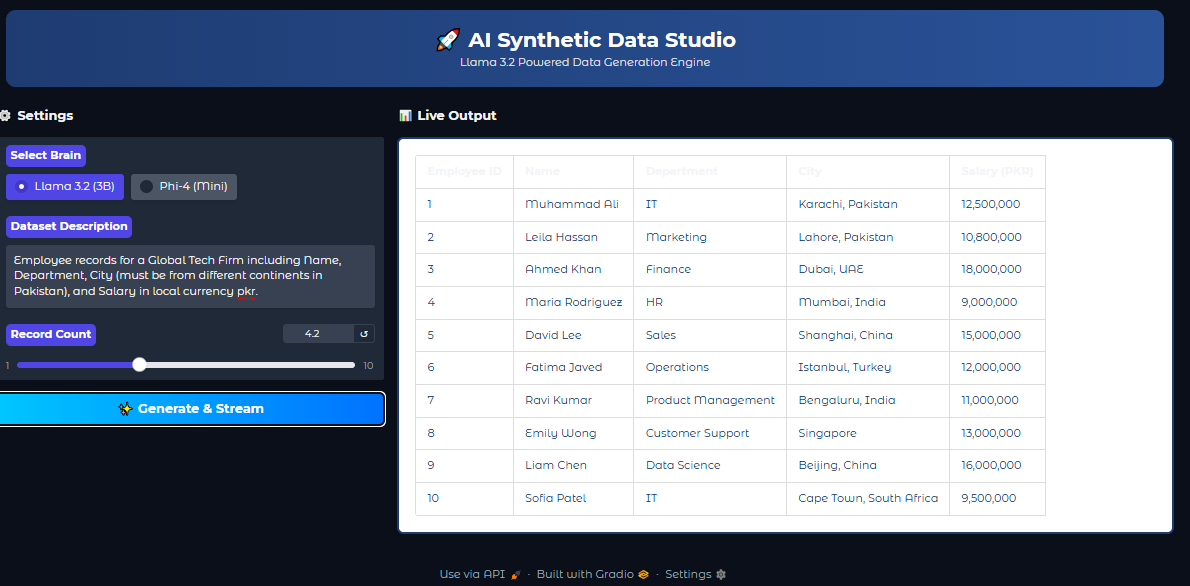

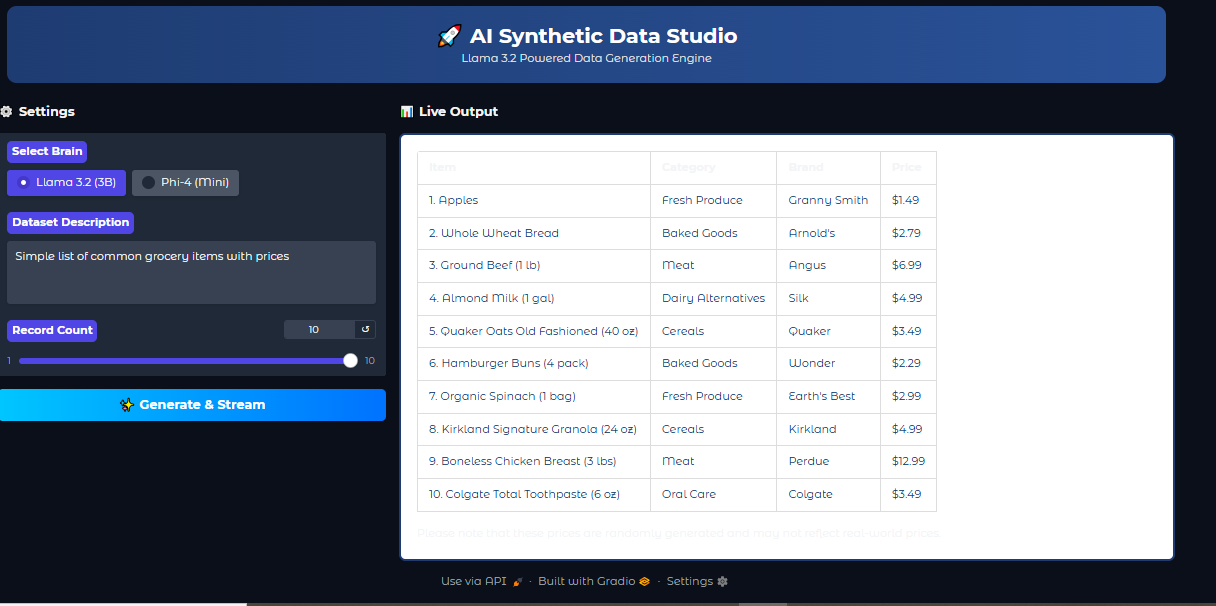

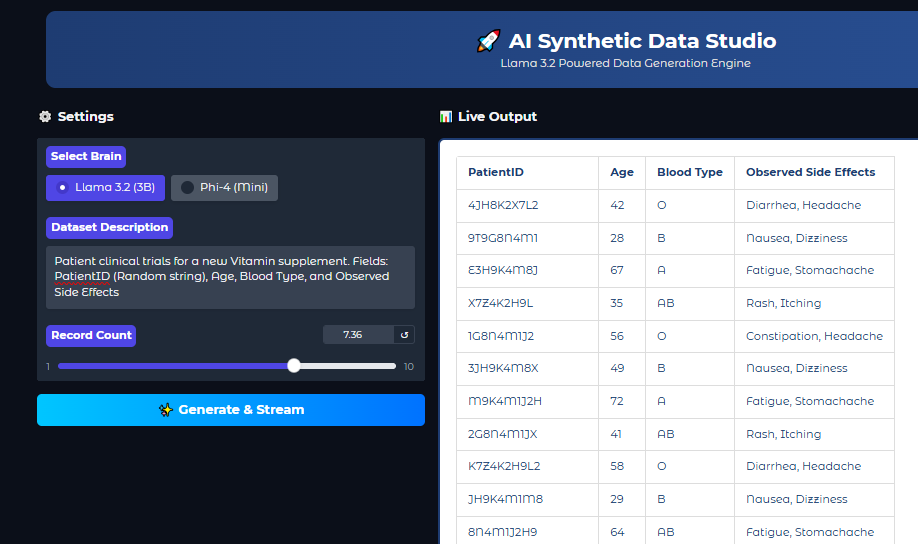